<a href="https://colab.research.google.com/github/basburak/makine_final/blob/main/yapay_zeka_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Performans ve İstatistiksel Analiz Raporu

In [23]:
import pandas as pd

# Load the normal radiomics data
df_normal = pd.read_csv('/content/normal_radiomics.csv')
df_normal['target'] = 0  # Assign label 0 for 'Normal'

# Load the papiledema radiomics data
df_papiledema = pd.read_csv('/content/papilodem_radiomics.csv')
df_papiledema['target'] = 1  # Assign label 1 for 'Papilödem'

print("Normal Radiomics DataFrame:")
display(df_normal.head())
print("Papilödem Radiomics DataFrame:")
display(df_papiledema.head())

Normal Radiomics DataFrame:


,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0738,Feature_0739,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746,target
0,1,Right,45448743,45448743,6.636275,13,26,95,163,57.307637,...,0.303150,5.687919,2.473651,0.125228,9.296632,0.021759,1.306864,3.731575,298.961246,0
1,1,Right,33362854,33362854,6.321687,13,28,87,121,55.412374,...,0.294247,5.846466,2.464606,0.344254,4.255490,0.068561,0.680029,9.035579,136.066301,0
2,1,Right,30680223,30680223,6.214364,20,28,83,114,54.242223,...,0.301285,5.535349,2.472294,0.125899,9.254451,0.020573,1.257392,3.786161,298.993921,0
3,1,Right,38885845,38885845,6.443296,21,31,91,143,60.356027,...,0.312013,5.530567,2.494216,0.125414,9.324893,0.021415,1.448996,3.622940,289.354936,0
4,1,Right,36867702,36867702,6.396227,21,31,91,129,59.868649,...,0.311296,5.672677,2.472707,0.125754,9.332594,0.023086,1.307401,3.652652,293.592461,0


Papilödem Radiomics DataFrame:


,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0738,Feature_0739,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746,target
0,1,Right,30259276,30259276,6.175943,19,29,77,165,50.778757,...,0.436097,4.264210,2.693133,0.068295,16.559611,0.011433,2.362870,1.591344,406.879968,1
1,1,Right,28490306,28490306,6.164030,18,28,75,166,49.993481,...,0.438471,4.489069,2.681561,0.068916,16.438471,0.012255,2.385825,1.646766,414.949181,1
2,1,Right,30701628,30701628,6.256489,16,27,80,167,50.490604,...,0.470351,4.388110,2.723603,0.135172,9.631323,0.028018,1.511648,2.851264,225.815864,1
3,1,Right,27817329,27817329,6.143411,17,26,72,168,48.220212,...,0.445624,4.502508,2.699718,0.069137,16.604529,0.013476,2.507635,1.650222,419.003235,1
4,1,Right,28759518,28759518,6.217389,14,26,75,170,48.372624,...,0.477801,4.688352,2.759445,0.069034,16.628858,0.012178,2.602866,1.614236,413.924248,1


/tmp/ipykernel_5498/3146994672.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_mrmr_features_sorted.index, y=mi_mrmr_features_sorted.values, palette='viridis')


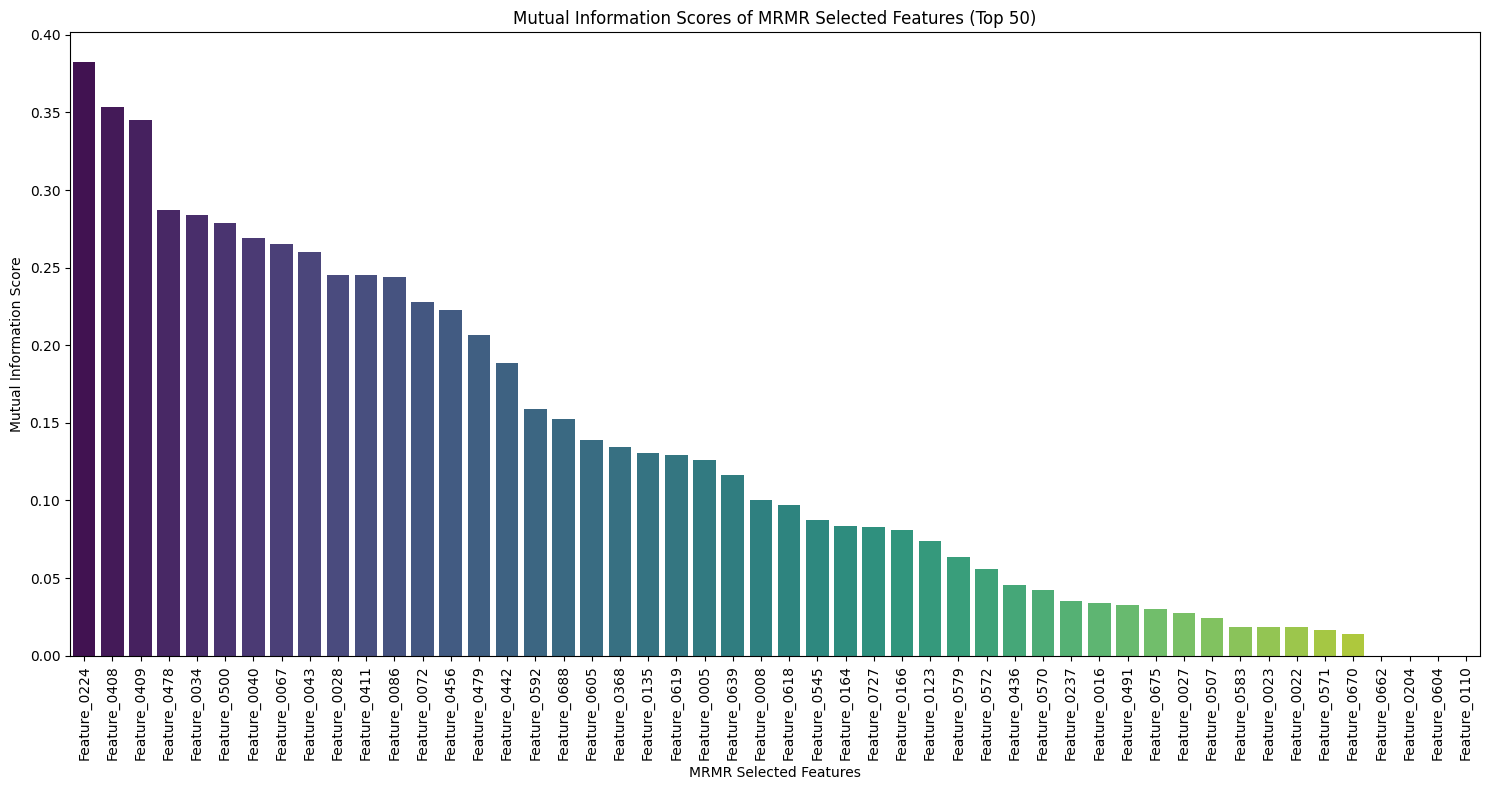

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# --- START: Code to ensure X_filtered_correlated_df and y are defined ---
# This block is re-included to make the cell self-contained and resolve the NameError.
# In a typical sequential notebook execution, these steps would run in preceding cells.

# 1. Concatenate the two dataframes (from cell d214a88e, assuming df_normal and df_papiledema are loaded)
df_combined = pd.concat([df_normal, df_papiledema], ignore_index=True)

# 2. Separate features (X) and target (y) (from cell bee2ad31)
X = df_combined.drop('target', axis=1)
y = df_combined['target']

# 3. Preprocessing steps to get X_filtered_correlated_df (from cell fdd05535)
X_preprocessed = X.drop(columns=['PatientIndex', 'SideStandard'])
X_preprocessed.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_preprocessed)
X_imputed_df = pd.DataFrame(X_imputed, columns=X_preprocessed.columns)
selector = VarianceThreshold(threshold=0)
X_filtered_variance = selector.fit_transform(X_imputed_df)
selected_features_variance = X_imputed_df.columns[selector.get_support()]
X_filtered_variance_df = pd.DataFrame(X_filtered_variance, columns=selected_features_variance)
corr_matrix = X_filtered_variance_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
X_filtered_correlated_df = X_filtered_variance_df.drop(columns=to_drop_corr)
# --- END: Code to ensure X_filtered_correlated_df and y are defined ---

# --- Code to re-define mi_series and selected_features_mrmr (originally from cell fdd05535) ---
# Now, X_filtered_correlated_df and y are guaranteed to be available.

num_mrmr_features = 50 # As defined in the original MRMR cell

# Calculate relevance (Mutual Information) for all features with the target 'y'
mi_scores = mutual_info_classif(X_filtered_correlated_df, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_filtered_correlated_df.columns)
mi_series = mi_series.sort_values(ascending=False)

selected_features_mrmr = []
unselected_features = list(mi_series.index)

# Start with the most relevant feature
if unselected_features:
    best_first_feature = mi_series.index[0]
    selected_features_mrmr.append(best_first_feature)
    unselected_features.remove(best_first_feature)

for _ in range(min(num_mrmr_features - 1, len(unselected_features))):
    best_mrmr_score = -np.inf
    feature_to_add = None

    for candidate_feature in unselected_features:
        relevance = mi_series[candidate_feature]
        redundancy_sum = 0
        for sf in selected_features_mrmr:
            corr_val = X_filtered_correlated_df[candidate_feature].corr(X_filtered_correlated_df[sf])
            if pd.isna(corr_val):
                corr_val = 0
            redundancy_sum += abs(corr_val)

        redundancy = redundancy_sum / len(selected_features_mrmr) if selected_features_mrmr else 0
        mrmr_score = relevance - redundancy

        if mrmr_score > best_mrmr_score:
            best_mrmr_score = mrmr_score
            feature_to_add = candidate_feature

    if feature_to_add:
        selected_features_mrmr.append(feature_to_add)
        unselected_features.remove(feature_to_add)
    else:
        break
# --- End of re-definition code for mi_series and selected_features_mrmr ---

# Filter mi_series for the selected MRMR features
mi_mrmr_features = mi_series[selected_features_mrmr]

# Sort the features by MI score in descending order
mi_mrmr_features_sorted = mi_mrmr_features.sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x=mi_mrmr_features_sorted.index, y=mi_mrmr_features_sorted.values, hue=mi_mrmr_features_sorted.index, palette='viridis', legend=False)
plt.xticks(rotation=90) # Rotate feature names for better readability
plt.xlabel('MRMR Selected Features')
plt.ylabel('Mutual Information Score')
plt.title('Mutual Information Scores of MRMR Selected Features (Top 50)')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [25]:
# Concatenate the two dataframes
df_combined = pd.concat([df_normal, df_papiledema], ignore_index=True)

# Display the first 5 rows of the combined dataframe
display(df_combined.head())

# Display the shape of the combined dataframe
print(f"Shape of the combined dataframe: {df_combined.shape}")

,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0738,Feature_0739,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746,target
0,1,Right,45448743,45448743,6.636275,13,26,95,163,57.307637,...,0.303150,5.687919,2.473651,0.125228,9.296632,0.021759,1.306864,3.731575,298.961246,0
1,1,Right,33362854,33362854,6.321687,13,28,87,121,55.412374,...,0.294247,5.846466,2.464606,0.344254,4.255490,0.068561,0.680029,9.035579,136.066301,0
2,1,Right,30680223,30680223,6.214364,20,28,83,114,54.242223,...,0.301285,5.535349,2.472294,0.125899,9.254451,0.020573,1.257392,3.786161,298.993921,0
3,1,Right,38885845,38885845,6.443296,21,31,91,143,60.356027,...,0.312013,5.530567,2.494216,0.125414,9.324893,0.021415,1.448996,3.622940,289.354936,0
4,1,Right,36867702,36867702,6.396227,21,31,91,129,59.868649,...,0.311296,5.672677,2.472707,0.125754,9.332594,0.023086,1.307401,3.652652,293.592461,0


Shape of the combined dataframe: (966, 749)


In [26]:
# Separate features (X) and target (y)
X = df_combined.drop('target', axis=1)
y = df_combined['target']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Check for missing values in X and y
missing_values_X = X.isnull().sum().sum()
missing_values_y = y.isnull().sum().sum()

if missing_values_X == 0 and missing_values_y == 0:
    print("No missing values found in the features (X) or target (y).")
else:
    print(f"Missing values in X: {missing_values_X}")
    print(f"Missing values in y: {missing_values_y}")

Shape of features (X): (966, 748)
Shape of target (y): (966,)
No missing values found in the features (X) or target (y).


In [27]:
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
import numpy as np
import pandas as pd

# 1. Drop non-feature columns from X
X_preprocessed = X.drop(columns=['PatientIndex', 'SideStandard'])

# 2. Replace infinite values with NaN
X_preprocessed.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Median Imputation
print("Applying Median Imputation...")
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_preprocessed)
X_imputed_df = pd.DataFrame(X_imputed, columns=X_preprocessed.columns)

# 4. Low Variance Feature Removal
print("Applying Low Variance Filtering...")
# Remove features with zero variance (constant features)
selector = VarianceThreshold(threshold=0)
X_filtered_variance = selector.fit_transform(X_imputed_df)
# Get the names of the selected features
selected_features_variance = X_imputed_df.columns[selector.get_support()]
X_filtered_variance_df = pd.DataFrame(X_filtered_variance, columns=selected_features_variance)
print(f"Shape after low variance filtering: {X_filtered_variance_df.shape}")

# 5. Correlation-Based Feature Elimination
print("Applying Correlation-Based Feature Elimination...")
# Calculate the correlation matrix
corr_matrix = X_filtered_variance_df.corr().abs()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

# Drop highly correlated features
X_filtered_correlated_df = X_filtered_variance_df.drop(columns=to_drop_corr)
print(f"Shape after correlation-based feature elimination: {X_filtered_correlated_df.shape}")

# 6. MRMR Feature Selection (Minimum Redundancy Maximum Relevance)
print("Applying MRMR Feature Selection (50 features)...")
num_mrmr_features = 50 # Number of features to select with MRMR

# Calculate relevance (Mutual Information) for all features with the target 'y'
# We use X_filtered_correlated_df as the input for MI calculation
mi_scores = mutual_info_classif(X_filtered_correlated_df, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_filtered_correlated_df.columns)
mi_series = mi_series.sort_values(ascending=False)

selected_features_mrmr = []
unselected_features = list(mi_series.index)

# Start with the most relevant feature
if unselected_features:
    best_first_feature = mi_series.index[0]
    selected_features_mrmr.append(best_first_feature)
    unselected_features.remove(best_first_feature)

for _ in range(min(num_mrmr_features - 1, len(unselected_features))): # Select remaining features
    best_mrmr_score = -np.inf
    feature_to_add = None

    for candidate_feature in unselected_features:
        # Relevance: Mutual Information
        relevance = mi_series[candidate_feature]

        # Redundancy: Average Pearson correlation with already selected features
        # We calculate redundancy using absolute Pearson correlation
        redundancy_sum = 0
        for sf in selected_features_mrmr:
            # Handle cases where correlation might be NaN (e.g., constant feature)
            corr_val = X_filtered_correlated_df[candidate_feature].corr(X_filtered_correlated_df[sf])
            if pd.isna(corr_val):
                corr_val = 0 # Treat NaN correlation as 0 redundancy
            redundancy_sum += abs(corr_val)

        redundancy = redundancy_sum / len(selected_features_mrmr) if selected_features_mrmr else 0

        mrmr_score = relevance - redundancy

        if mrmr_score > best_mrmr_score:
            best_mrmr_score = mrmr_score
            feature_to_add = candidate_feature

    if feature_to_add:
        selected_features_mrmr.append(feature_to_add)
        unselected_features.remove(feature_to_add)
    else:
        # If no feature could be added (e.g., all remaining have zero relevance or too high redundancy)
        break

X_mrmr_selected = X_filtered_correlated_df[selected_features_mrmr]
print(f"Shape after MRMR feature selection ({len(selected_features_mrmr)} features selected): {X_mrmr_selected.shape}")

# 7. Robust Scaling
print("Applying Robust Scaling to MRMR selected features...")
scaler = RobustScaler()
X_scaled_final = scaler.fit_transform(X_mrmr_selected)

# Convert the final scaled features back to a DataFrame for easier inspection
X_scaled_final_df = pd.DataFrame(X_scaled_final, columns=selected_features_mrmr)

print("\nFirst 5 rows of fully preprocessed, MRMR selected, and scaled features:")
display(X_scaled_final_df.head())
print(f"Shape of final scaled features (X_scaled_final): {X_scaled_final.shape}")

# Update X_scaled to be X_scaled_final for subsequent cells
X_scaled = X_scaled_final

Applying Median Imputation...
Applying Low Variance Filtering...
Shape after low variance filtering: (966, 739)
Applying Correlation-Based Feature Elimination...
Shape after correlation-based feature elimination: (966, 235)
Applying MRMR Feature Selection (50 features)...
Shape after MRMR feature selection (50 features selected): (966, 50)
Applying Robust Scaling to MRMR selected features...

First 5 rows of fully preprocessed, MRMR selected, and scaled features:


,Feature_0224,Feature_0688,Feature_0570,Feature_0409,Feature_0005,Feature_0166,Feature_0028,Feature_0022,Feature_0123,Feature_0408,...,Feature_0016,Feature_0008,Feature_0579,Feature_0618,Feature_0670,Feature_0442,Feature_0110,Feature_0604,Feature_0479,Feature_0572
0,-0.248370,0.155050,-0.278116,0.403578,-1.019608,-0.412411,-0.073514,0.436346,-0.191018,-0.906969,...,1.229024,-0.715702,0.074496,1.697388,-0.075066,-0.370844,-0.197914,0.157659,0.0,0.0
1,-0.022574,-3.058345,-0.389193,-0.044040,-0.862745,0.124444,-0.347882,-0.108511,-0.050881,-0.304682,...,-0.524730,-0.806212,-0.397155,2.419124,-0.247504,0.125309,0.241403,-0.305243,0.0,0.0
2,-0.117872,-0.852306,-0.294624,-0.303420,-0.862745,-0.056741,-0.701748,-0.520541,-0.397749,0.000169,...,-0.712223,-0.862094,-0.427645,0.663834,-1.009975,0.475281,-0.134647,-0.129400,0.0,0.0
3,-0.190504,0.103641,-0.383990,0.042665,-0.627451,-0.481135,-0.432283,-0.048082,0.968505,-0.270310,...,0.119694,-0.570123,0.069533,0.165993,-0.428320,-0.450733,0.246009,0.730895,0.0,0.0
4,-0.119098,-0.976452,-0.247285,0.020862,-0.627451,-0.811185,-0.472467,0.358613,0.869730,-0.288533,...,-0.345778,-0.593398,0.452746,0.259971,-1.639549,-0.321171,1.560888,0.204592,0.0,0.0


Shape of final scaled features (X_scaled_final): (966, 50)


In [28]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets using the fully preprocessed and MRMR-selected features (X_scaled)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (676, 50)
Shape of X_test: (290, 50)
Shape of y_train: (676,)
Shape of y_test: (290,)


### Hyperparameter Optimization with Optuna for Random Forest

In [29]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00


In [30]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer
import numpy as np

# Define the objective function for Optuna
def objective(trial):
    # Hyperparameters to tune
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7, 0.9]) # Added more options for max_features
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    # Random Forest Classifier with suggested hyperparameters
    classifier = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        random_state=42,
        n_jobs=-1 # Use all available cores
    )

    # Use StratifiedKFold for cross-validation
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Calculate Macro-F1 score using cross-validation
    macro_f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(classifier, X_train, y_train, cv=kf, scoring=macro_f1_scorer)

    # Return the mean Macro-F1 score
    return scores.mean()

# Create a study object and optimize the objective function
# Use TPE sampler as requested
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50) # Run at least 50 trials as requested

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2026-06-28 06:47:24,126] A new study created in memory with name: no-name-be74dc61-4629-4a8d-8566-087d95d21441
[I 2026-06-28 06:47:31,359] Trial 0 finished with value: 0.925719207994016 and parameters: {'n_estimators': 144, 'max_depth': 48, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.7, 'criterion': 'gini'}. Best is trial 0 with value: 0.925719207994016.
[I 2026-06-28 06:47:42,805] Trial 1 finished with value: 0.9381943578001728 and parameters: {'n_estimators': 293, 'max_depth': 43, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 0.5, 'criterion': 'gini'}. Best is trial 1 with value: 0.9381943578001728.
[I 2026-06-28 06:47:48,983] Trial 2 finished with value: 0.9190892320765744 and parameters: {'n_estimators': 123, 'max_depth': 21, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 0.9, 'criterion': 'gini'}. Best is trial 1 with value: 0.9381943578001728.
[I 2026-06-28 06:47:54,045] Trial 3 finished with value: 0.9266395937916222 and

Number of finished trials:  50
Best trial:
  Value: 0.9458314634319167
  Params: 
    n_estimators: 285
    max_depth: 31
    min_samples_split: 3
    min_samples_leaf: 1
    max_features: 0.5
    criterion: entropy


## 7. Hiperparametre Optimizasyonu

### Retraining Random Forest with Best Hyperparameters and Evaluation

## 8. Sonuçlar

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Get the best hyperparameters from Optuna study
best_params = study.best_params

# Initialize a new Random Forest Classifier with the best hyperparameters
# Ensure we train on X_train directly, not X_train_pca
optimized_rf_model = RandomForestClassifier(random_state=42, **best_params, n_jobs=-1)

# Train the model on the training data (X_train which contains MRMR-selected features)
optimized_rf_model.fit(X_train, y_train)

print("Optimized Random Forest model trained successfully!")

# Make predictions on the test data (X_test which contains MRMR-selected features)
y_pred_optimized_rf = optimized_rf_model.predict(X_test)

# Evaluate the Optimized Random Forest model
accuracy_optimized_rf = accuracy_score(y_test, y_pred_optimized_rf)
precision_optimized_rf = precision_score(y_test, y_pred_optimized_rf, average='macro') # Macro precision
recall_optimized_rf = recall_score(y_test, y_pred_optimized_rf, average='macro')   # Macro recall
f1_optimized_rf = f1_score(y_test, y_pred_optimized_rf, average='macro')       # Macro F1-score

print(f"\nOptimized Random Forest Model Accuracy: {accuracy_optimized_rf:.4f}")
print(f"Optimized Random Forest Model Macro Precision: {precision_optimized_rf:.4f}")
print(f"Optimized Random Forest Model Macro Recall: {recall_optimized_rf:.4f}")
print(f"Optimized Random Forest Model Macro F1-Score: {f1_optimized_rf:.4f}")

print("\nOptimized Random Forest Classification Report:")
print(classification_report(y_test, y_pred_optimized_rf))

Optimized Random Forest model trained successfully!

Optimized Random Forest Model Accuracy: 0.9759
Optimized Random Forest Model Macro Precision: 0.9795
Optimized Random Forest Model Macro Recall: 0.9634
Optimized Random Forest Model Macro F1-Score: 0.9710

Optimized Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       202
           1       0.99      0.93      0.96        88

    accuracy                           0.98       290
   macro avg       0.98      0.96      0.97       290
weighted avg       0.98      0.98      0.98       290



### PCA is no longer needed after MRMR feature selection

Since MRMR has already reduced the number of features to 50, applying PCA afterwards is redundant and could potentially remove useful variance from the already selected features. Therefore, the subsequent cells will use the `X_train` and `X_test` directly without further PCA transformation. The original PCA cell `787541f0` will be skipped for the final model training and evaluation.

### Inner Cross Validation with StratifiedGroupKFold

In [32]:
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer
import numpy as np

# Get the PatientIndex for the training data to use as groups
# Since y_train retains the original indices from df_combined, we can use them to extract PatientIndex.
# Make sure df_combined is accessible in this scope.
# If df_combined.index is not aligned with y_train.index, an error may occur.
# We assume y_train.index accurately reflects the indices from the original df_combined for the training set.
groups_train = df_combined.loc[y_train.index, 'PatientIndex']

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of groups_train: {groups_train.shape}")

# Instantiate StratifiedGroupKFold
# Using 5 splits as a common practice for inner cross-validation
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Define the Macro-F1 scorer
macro_f1_scorer = make_scorer(f1_score, average='macro')

print("\nPerforming Inner Cross Validation on the optimized Random Forest model...")

# Perform cross-validation on the training set using the optimized model and groups
cv_scores_optimized_rf = cross_val_score(
    optimized_rf_model, # The model already optimized by Optuna
    X_train,
    y_train,
    groups=groups_train, # Pass the patient groups
    cv=sgkf,
    scoring=macro_f1_scorer,
    n_jobs=-1 # Use all available cores
)

print(f"Inner Cross-Validation Macro-F1 Scores: {cv_scores_optimized_rf}")
print(f"Mean Inner CV Macro-F1 Score: {np.mean(cv_scores_optimized_rf):.4f}")
print(f"Standard Deviation of Inner CV Macro-F1 Score: {np.std(cv_scores_optimized_rf):.4f}")

Shape of X_train: (676, 50)
Shape of y_train: (676,)
Shape of groups_train: (676,)

Performing Inner Cross Validation on the optimized Random Forest model...
Inner Cross-Validation Macro-F1 Scores: [0.7126352  0.93716755 0.86795964 1.         0.9739704 ]
Mean Inner CV Macro-F1 Score: 0.8983
Standard Deviation of Inner CV Macro-F1 Score: 0.1029


/tmp/ipykernel_5498/1026446872.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fold_indices, y=cv_scores_optimized_rf, palette='viridis')


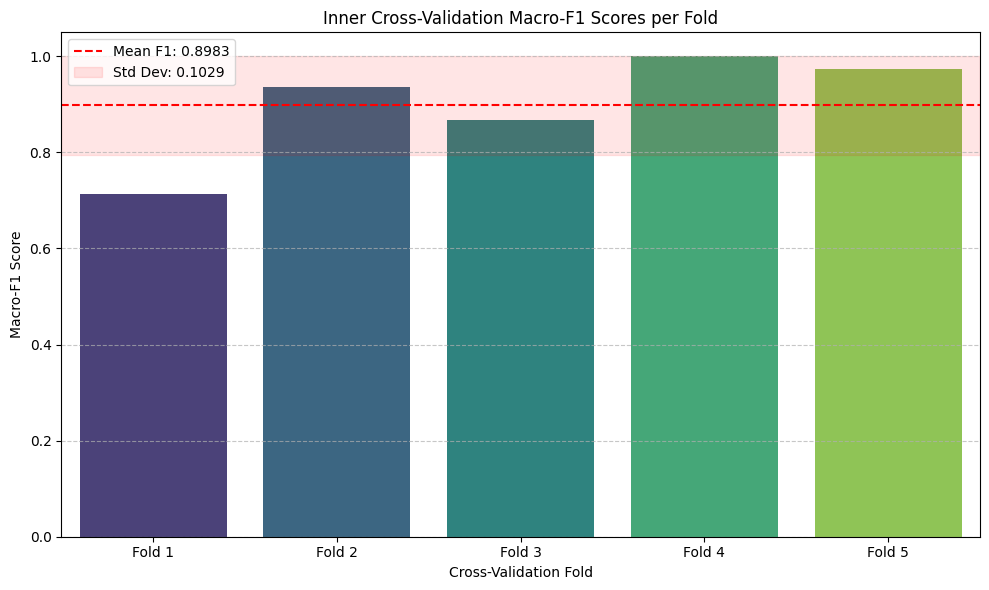

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
fold_indices = [f'Fold {i+1}' for i in range(len(cv_scores_optimized_rf))]

fig = plt.figure(figsize=(10, 6))
sns.barplot(x=fold_indices, y=cv_scores_optimized_rf, palette='viridis')
plt.axhline(np.mean(cv_scores_optimized_rf), color='r', linestyle='--', label=f'Mean F1: {np.mean(cv_scores_optimized_rf):.4f}')
plt.axhspan(np.mean(cv_scores_optimized_rf) - np.std(cv_scores_optimized_rf),
            np.mean(cv_scores_optimized_rf) + np.std(cv_scores_optimized_rf),
            color='r', alpha=0.1, label=f'Std Dev: {np.std(cv_scores_optimized_rf):.4f}')
plt.title('Inner Cross-Validation Macro-F1 Scores per Fold')
plt.xlabel('Cross-Validation Fold')
plt.ylabel('Macro-F1 Score')
plt.ylim(0, 1.05) # Set y-axis limit for F1 scores
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Inner Cross-Validation Results Summary Table

In [34]:
import pandas as pd
import numpy as np

# Create a DataFrame to display the results
cv_results_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(len(cv_scores_optimized_rf))],
    'Macro-F1 Score': cv_scores_optimized_rf
})

# Add mean and standard deviation as summary rows
mean_f1 = np.mean(cv_scores_optimized_rf)
std_f1 = np.std(cv_scores_optimized_rf)

summary_df = pd.DataFrame([
    {'Fold': 'Mean', 'Macro-F1 Score': mean_f1},
    {'Fold': 'Standard Deviation', 'Macro-F1 Score': std_f1}
])

cv_results_df = pd.concat([cv_results_df, summary_df], ignore_index=True)

display(cv_results_df)

,Fold,Macro-F1 Score
0,Fold 1,0.712635
1,Fold 2,0.937168
2,Fold 3,0.867960
3,Fold 4,1.000000
4,Fold 5,0.973970
5,Mean,0.898347
6,Standard Deviation,0.102929


### Model Calibration: Sigmoid Calibration

In [35]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score, f1_score, classification_report

# Initialize the Calibrated Classifier with the optimized Random Forest model
# using 'sigmoid' method as requested
calibrated_rf_model = CalibratedClassifierCV(optimized_rf_model, method='sigmoid', cv='prefit')

# Fit the calibrated model on the training data
# Since we set cv='prefit', the base estimator (optimized_rf_model) should already be fitted.
# CalibratedClassifierCV will use the pre-fitted model to train the calibrator on the training data.
# Note: If optimized_rf_model was not pre-fitted, we would fit calibrated_rf_model directly on X_train, y_train, and it would handle fitting the base_estimator internally through cross-validation.
calibrated_rf_model.fit(X_train, y_train)

print("Random Forest model calibrated using Sigmoid method successfully!")

# Predict probabilities on the test set using the calibrated model
y_prob_calibrated = calibrated_rf_model.predict_proba(X_test)[:, 1]
y_pred_calibrated = calibrated_rf_model.predict(X_test)

# Evaluate the calibrated model
accuracy_calibrated = accuracy_score(y_test, y_pred_calibrated)
f1_calibrated = f1_score(y_test, y_pred_calibrated, average='macro')
logloss_calibrated = log_loss(y_test, y_prob_calibrated)
brier_calibrated = brier_score_loss(y_test, y_prob_calibrated)

print(f"\nCalibrated Random Forest Model Accuracy: {accuracy_calibrated:.4f}")
print(f"Calibrated Random Forest Model Macro F1-Score: {f1_calibrated:.4f}")
print(f"Calibrated Random Forest Model Log Loss: {logloss_calibrated:.4f}")
print(f"Calibrated Random Forest Model Brier Score Loss: {brier_calibrated:.4f}")

print("\nCalibrated Random Forest Classification Report:")
print(classification_report(y_test, y_pred_calibrated))

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Random Forest model calibrated using Sigmoid method successfully!

Calibrated Random Forest Model Accuracy: 0.9759
Calibrated Random Forest Model Macro F1-Score: 0.9710
Calibrated Random Forest Model Log Loss: 0.0553
Calibrated Random Forest Model Brier Score Loss: 0.0152

Calibrated Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       202
           1       0.99      0.93      0.96        88

    accuracy                           0.98       290
   macro avg       0.98      0.96      0.97       290
weighted avg       0.98      0.98      0.98       290



### Calibration Curve

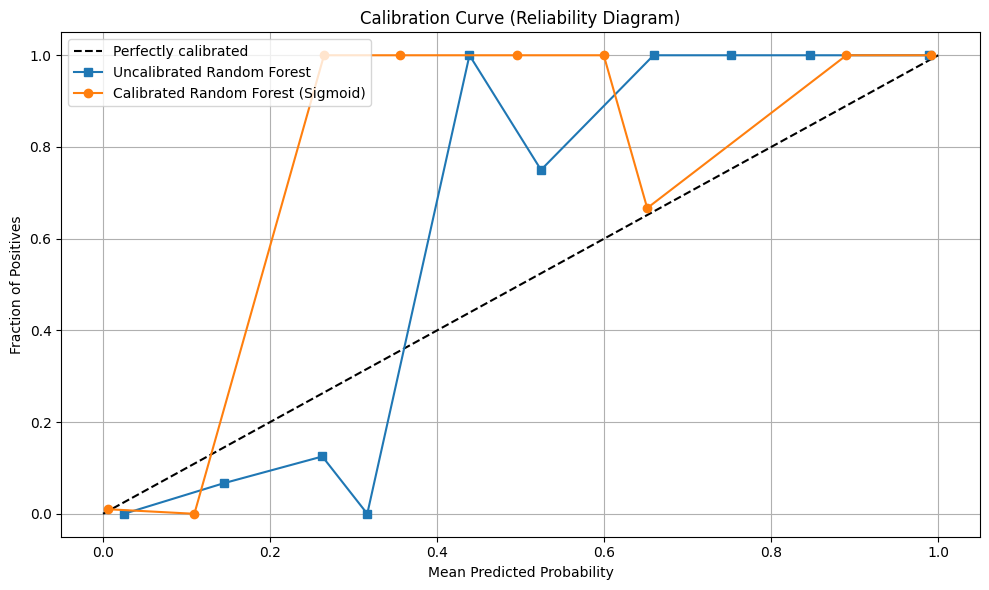

In [36]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Uncalibrated model probabilities
y_prob_uncalibrated = optimized_rf_model.predict_proba(X_test)[:, 1]

# Calculate calibration curves
fop_uncalibrated, mpv_uncalibrated = calibration_curve(y_test, y_prob_uncalibrated, n_bins=10)
fop_calibrated, mpv_calibrated = calibration_curve(y_test, y_prob_calibrated, n_bins=10)

# Plot calibration curves
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated') # Diagonal line
plt.plot(mpv_uncalibrated, fop_uncalibrated, 's-', label='Uncalibrated Random Forest')
plt.plot(mpv_calibrated, fop_calibrated, 'o-', label='Calibrated Random Forest (Sigmoid)')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Ensemble Model: Soft Voting Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Define the individual classifiers
# Optimized Random Forest (from previous steps)
rf_clf = optimized_rf_model

# Extra Trees Classifier
# Using reasonable defaults for initial ensemble. Hyperparameter tuning could be applied here as well.
et_clf = ExtraTreesClassifier(random_state=42, n_jobs=-1)

# Gradient Boosting Classifier
# Using reasonable defaults for initial ensemble. Hyperparameter tuning could be applied here as well.
gb_clf = GradientBoostingClassifier(random_state=42)

# 2. Create the Soft Voting Ensemble Classifier
# 'weights' can be adjusted based on individual model performance or further optimization
ensemble_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('et', et_clf), ('gb', gb_clf)],
    voting='soft', # Use soft voting for probability averaging
    n_jobs=-1 # Use all available cores for parallel processing of base estimators
)

# 3. Train the ensemble model
print("Training the Soft Voting Ensemble Classifier...")
ensemble_clf.fit(X_train, y_train)
print("Ensemble model trained successfully!")

# 4. Make predictions on the test data
y_pred_ensemble = ensemble_clf.predict(X_test)

# 5. Evaluate the ensemble model
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
precision_ensemble = precision_score(y_test, y_pred_ensemble, average='macro')
recall_ensemble = recall_score(y_test, y_pred_ensemble, average='macro')
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='macro')

print(f"\nEnsemble Model Accuracy: {accuracy_ensemble:.4f}")
print(f"Ensemble Model Macro Precision: {precision_ensemble:.4f}")
print(f"Ensemble Model Macro Recall: {recall_ensemble:.4f}")
print(f"Ensemble Model Macro F1-Score: {f1_ensemble:.4f}")

print("\nEnsemble Model Classification Report:")
print(classification_report(y_test, y_pred_ensemble))

Training the Soft Voting Ensemble Classifier...
Ensemble model trained successfully!

Ensemble Model Accuracy: 0.9793
Ensemble Model Macro Precision: 0.9856
Ensemble Model Macro Recall: 0.9659
Ensemble Model Macro F1-Score: 0.9750

Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       202
           1       1.00      0.93      0.96        88

    accuracy                           0.98       290
   macro avg       0.99      0.97      0.98       290
weighted avg       0.98      0.98      0.98       290



### Model Performance Comparison: Optimized Random Forest vs. Soft Voting Ensemble

In [38]:
import pandas as pd

# Metrics for Optimized Random Forest Model (from previous evaluation)
rf_metrics = {
    'Model': 'Optimized Random Forest',
    'Accuracy': accuracy_optimized_rf,
    'Macro Precision': precision_optimized_rf,
    'Macro Recall': recall_optimized_rf,
    'Macro F1-Score': f1_optimized_rf
}

# Metrics for Soft Voting Ensemble Model (from previous evaluation)
ensemble_metrics = {
    'Model': 'Soft Voting Ensemble',
    'Accuracy': accuracy_ensemble,
    'Macro Precision': precision_ensemble,
    'Macro Recall': recall_ensemble,
    'Macro F1-Score': f1_ensemble
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame([rf_metrics, ensemble_metrics])

# Display the comparison table
display(comparison_df.set_index('Model').round(4))

,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Optimized Random Forest,0.9759,0.9795,0.9634,0.971
Soft Voting Ensemble,0.9793,0.9856,0.9659,0.975


### Visual Comparison of Model Performance

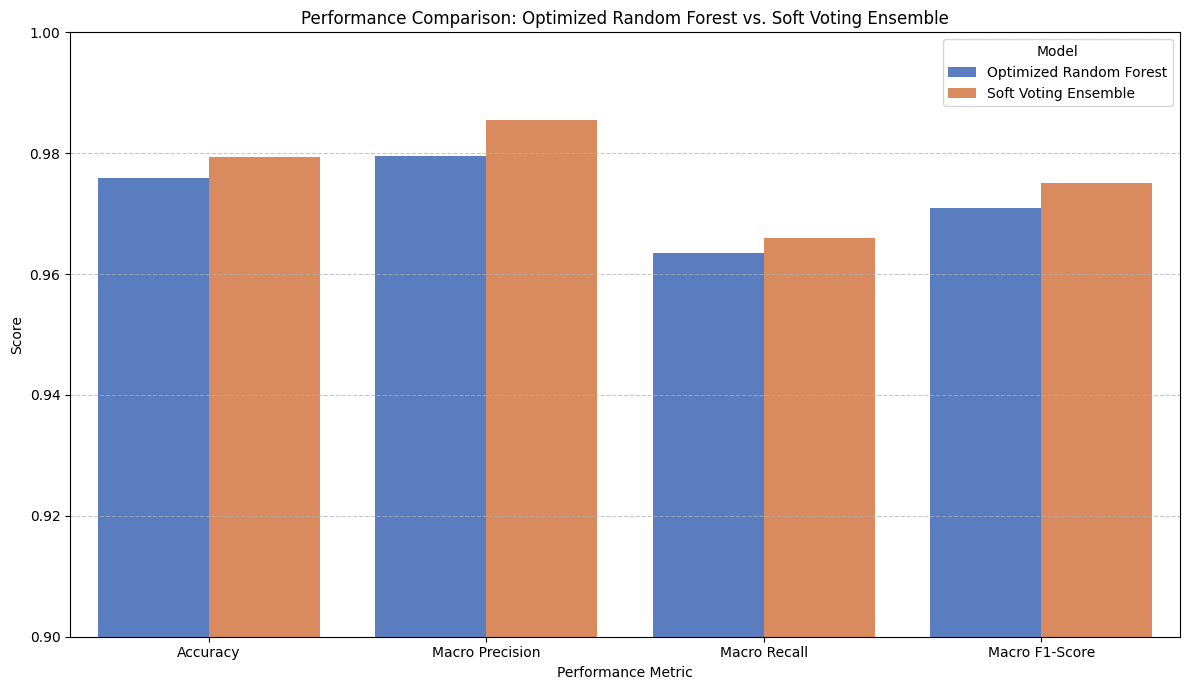

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the comparison DataFrame to a long format suitable for seaborn bar plot
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted, palette='muted')
plt.ylim(0.9, 1.0) # Set y-axis limits to better highlight the differences
plt.title('Performance Comparison: Optimized Random Forest vs. Soft Voting Ensemble')
plt.ylabel('Score')
plt.xlabel('Performance Metric')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ensemble Model Performance Metrics

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, balanced_accuracy_score, brier_score_loss, classification_report

# Make predictions and get probabilities on the test set
y_pred_ensemble = ensemble_clf.predict(X_test)
y_prob_ensemble = ensemble_clf.predict_proba(X_test)[:, 1]

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred_ensemble)

# 2. Precision, Recall, F1-score (for class 1 and macro-average)
precision_class_1 = precision_score(y_test, y_pred_ensemble, pos_label=1)
recall_class_1 = recall_score(y_test, y_pred_ensemble, pos_label=1)
f1_class_1 = f1_score(y_test, y_pred_ensemble, pos_label=1)

precision_macro = precision_score(y_test, y_pred_ensemble, average='macro')
recall_macro = recall_score(y_test, y_pred_ensemble, average='macro')
f1_macro = f1_score(y_test, y_pred_ensemble, average='macro')

# 3. ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_ensemble)

# 4. PR-AUC (Area Under the Precision-Recall Curve)
pr_auc = average_precision_score(y_test, y_prob_ensemble)

# 5. Balanced Accuracy
balanced_accuracy = balanced_accuracy_score(y_test, y_pred_ensemble)

# 6. Brier Score (requires probabilities)
brier_score = brier_score_loss(y_test, y_prob_ensemble)

# Compile all metrics into a dictionary for display
ensemble_all_metrics = {
    "Metric": [
        "Accuracy",
        "Precision (Class 1)",
        "Recall (Class 1)",
        "F1-score (Class 1)",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Balanced Accuracy",
        "Brier Score"
    ],
    "Score": [
        accuracy,
        precision_class_1,
        recall_class_1,
        f1_class_1,
        precision_macro,
        recall_macro,
        f1_macro,
        roc_auc,
        pr_auc,
        balanced_accuracy,
        brier_score
    ]
}

metrics_df = pd.DataFrame(ensemble_all_metrics)
display(metrics_df.set_index('Metric').round(4))

print("\nFull Classification Report for Ensemble Model:")
print(classification_report(y_test, y_pred_ensemble))

,Score
Metric,
Accuracy,0.9793
Precision (Class 1),1.0000
Recall (Class 1),0.9318
F1-score (Class 1),0.9647
Macro Precision,0.9856
Macro Recall,0.9659
Macro F1-score,0.9750
ROC-AUC,0.9996
PR-AUC,0.9991



Full Classification Report for Ensemble Model:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       202
           1       1.00      0.93      0.96        88

    accuracy                           0.98       290
   macro avg       0.99      0.97      0.98       290
weighted avg       0.98      0.98      0.98       290



### ROC Curve for Ensemble Model

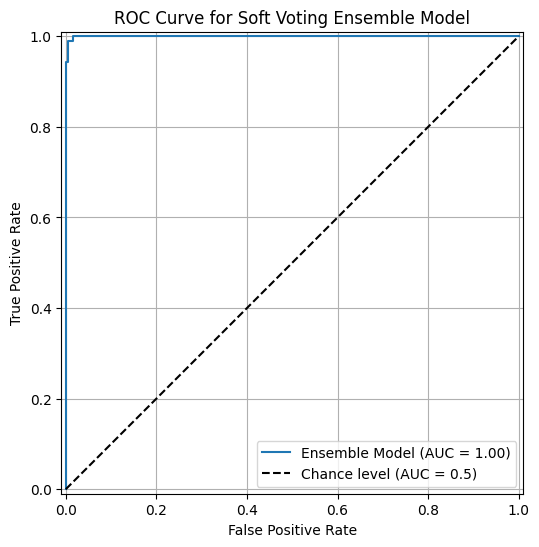

In [41]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    ensemble_clf, X_test, y_test, name='Ensemble Model',
    ax=ax, plot_chance_level=True
)
plt.title('ROC Curve for Soft Voting Ensemble Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

### Precision-Recall Curve for Ensemble Model

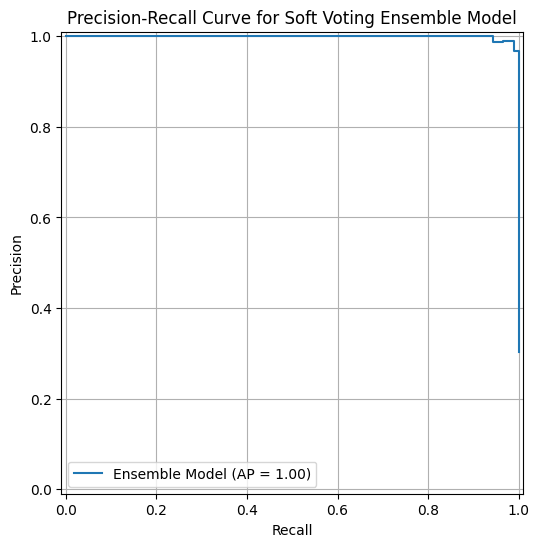

In [42]:
# Plot Precision-Recall curve
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(
    ensemble_clf, X_test, y_test, name='Ensemble Model',
    ax=ax
)
plt.title('Precision-Recall Curve for Soft Voting Ensemble Model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

In [43]:
print('Data preparation complete!\n')
print('Summary of prepared data:')
print(f'Combined DataFrame shape: {df_combined.shape}')
print(f'Features (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')
print(f'Scaled Features (X_scaled) shape: {X_scaled.shape}')
print(f'Training features (X_train) shape: {X_train.shape}')
print(f'Testing features (X_test) shape: {X_test.shape}')
print(f'Training target (y_train) shape: {y_train.shape}')
print(f'Testing target (y_test) shape: {y_test.shape}')

print('\nThe data is now ready for model training and evaluation. Do you want to proceed with model selection and training, or explore any other aspects of the data?')

Data preparation complete!

Summary of prepared data:
Combined DataFrame shape: (966, 749)
Features (X) shape: (966, 748)
Target (y) shape: (966,)
Scaled Features (X_scaled) shape: (966, 50)
Training features (X_train) shape: (676, 50)
Testing features (X_test) shape: (290, 50)
Training target (y_train) shape: (676,)
Testing target (y_test) shape: (290,)

The data is now ready for model training and evaluation. Do you want to proceed with model selection and training, or explore any other aspects of the data?


In [44]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize PCA - Let's start by reducing to 50 principal components as an initial guess
pca = PCA(n_components=50, random_state=42)

# Fit PCA on the training data and transform both training and test data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Shape of X_train after PCA: {X_train_pca.shape}")
print(f"Shape of X_test after PCA: {X_test_pca.shape}")

Shape of X_train after PCA: (676, 50)
Shape of X_test after PCA: (290, 50)


In [45]:
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and L1/L2 regularization

# Train the model on the PCA-transformed training data
log_reg_model.fit(X_train_pca, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [46]:
# Make predictions on the PCA-transformed test data
y_pred = log_reg_model.predict(X_test_pca)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9483
Model Precision: 0.9506
Model Recall: 0.8750
Model F1-Score: 0.9112

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       202
           1       0.95      0.88      0.91        88

    accuracy                           0.95       290
   macro avg       0.95      0.93      0.94       290
weighted avg       0.95      0.95      0.95       290



### Random Forest Model Training and Evaluation

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using some default parameters, these can be optimized later with Optuna
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)

# Train the model on the PCA-transformed training data
rf_model.fit(X_train_pca, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [48]:
# Make predictions on the PCA-transformed test data
y_pred_rf = rf_model.predict(X_test_pca)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Model Precision: {precision_rf:.4f}")
print(f"Random Forest Model Recall: {recall_rf:.4f}")
print(f"Random Forest Model F1-Score: {f1_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Model Accuracy: 0.9552
Random Forest Model Precision: 1.0000
Random Forest Model Recall: 0.8523
Random Forest Model F1-Score: 0.9202

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       202
           1       1.00      0.85      0.92        88

    accuracy                           0.96       290
   macro avg       0.97      0.93      0.94       290
weighted avg       0.96      0.96      0.95       290



### İstatistiksel Analiz: Friedman ve Wilcoxon Testleri

In [49]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, make_scorer
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.sandbox.stats.multicomp import multipletests

print("Çapraz doğrulama skorlarını toplama...")

# Instantiate StratifiedGroupKFold with the same parameters used previously
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
macro_f1_scorer = make_scorer(f1_score, average='macro')

# Get CV scores for Optimized Random Forest (already calculated as cv_scores_optimized_rf)
# If not already calculated or accessible, uncomment and run:
# cv_scores_optimized_rf = cross_val_score(optimized_rf_model, X_train, y_train, groups=groups_train, cv=sgkf, scoring=macro_f1_scorer, n_jobs=-1)

# Get CV scores for Extra Trees Classifier
print("Extra Trees model için çapraz doğrulama skorları hesaplanıyor...")
cv_scores_et_clf = cross_val_score(
    et_clf, # The ExtraTreesClassifier from the ensemble
    X_train, y_train, groups=groups_train, cv=sgkf, scoring=macro_f1_scorer, n_jobs=-1
)

# Get CV scores for Gradient Boosting Classifier
print("Gradient Boosting model için çapraz doğrulama skorları hesaplanıyor...")
cv_scores_gb_clf = cross_val_score(
    gb_clf, # The GradientBoostingClassifier from the ensemble
    X_train, y_train, groups=groups_train, cv=sgkf, scoring=macro_f1_scorer, n_jobs=-1
)

# Get CV scores for the Soft Voting Ensemble
print("Ensemble model için çapraz doğrulama skorları hesaplanıyor...")
cv_scores_ensemble_clf = cross_val_score(
    ensemble_clf, # The Soft Voting Ensemble Classifier
    X_train, y_train, groups=groups_train, cv=sgkf, scoring=macro_f1_scorer, n_jobs=-1
)

# Combine scores into a DataFrame for easier handling and Friedman test
model_scores = pd.DataFrame({
    'Optimized_RF': cv_scores_optimized_rf,
    'Extra_Trees': cv_scores_et_clf,
    'Gradient_Boosting': cv_scores_gb_clf,
    'Ensemble': cv_scores_ensemble_clf
})

display(model_scores)

print("\nFriedman Testi Uygulanıyor...")
# Perform Friedman test
stat, p_friedman = friedmanchisquare(*model_scores.values.T)
print(f"Friedman Test İstatistik: {stat:.4f}")
print(f"Friedman Test p-değeri: {p_friedman:.4f}")

if p_friedman < 0.05:
    print("Friedman testi, modeller arasında istatistiksel olarak anlamlı farklılıklar olduğunu gösteriyor. Post-hoc Wilcoxon testleri uygulanacak.")

    # Post-hoc Wilcoxon Signed-Rank Test with Bonferroni Correction
    alpha = 0.05
    comparisons = []
    p_values = []

    model_names = model_scores.columns

    # All possible pairwise comparisons
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            model1 = model_names[i]
            model2 = model_names[j]

            # Wilcoxon signed-rank test
            # We use `alternative='two-sided'` for general difference
            # If data is identical, wilcoxon returns nan for p-value
            try:
                stat_wilcoxon, p_wilcoxon = wilcoxon(model_scores[model1], model_scores[model2], alternative='two-sided')
            except ValueError: # Occurs if ranks are tied for all observations, or if all differences are zero
                p_wilcoxon = 1.0 # No significant difference if all values are the same

            comparisons.append(f'{model1} vs {model2}')
            p_values.append(p_wilcoxon)

    # Apply Bonferroni correction
    reject, p_values_corrected, _, _ = multipletests(p_values, alpha=alpha, method='bonferroni')

    results_df = pd.DataFrame({
        'Karşılaştırma': comparisons,
        'Wilcoxon p-değeri': p_values,
        'Bonferroni Düzeltmeli p-değeri': p_values_corrected,
        'Anlamlı Fark (p < 0.05)': reject
    })
    display(results_df)
else:
    print("Friedman testi, modeller arasında istatistiksel olarak anlamlı bir fark olmadığını gösteriyor.")

Çapraz doğrulama skorlarını toplama...
Extra Trees model için çapraz doğrulama skorları hesaplanıyor...
Gradient Boosting model için çapraz doğrulama skorları hesaplanıyor...
Ensemble model için çapraz doğrulama skorları hesaplanıyor...


,Optimized_RF,Extra_Trees,Gradient_Boosting,Ensemble
0,0.712635,0.723601,0.718103,0.718103
1,0.937168,0.925926,0.916223,0.914431
2,0.867960,0.865181,0.890244,0.880359
3,1.000000,1.000000,0.985131,1.000000
4,0.973970,0.965566,0.965566,0.973970



Friedman Testi Uygulanıyor...
Friedman Test İstatistik: 0.4884
Friedman Test p-değeri: 0.9214
Friedman testi, modeller arasında istatistiksel olarak anlamlı bir fark olmadığını gösteriyor.


In [50]:
print("Model Çapraz Doğrulama Macro-F1 Skorları:")
display(model_scores)

Model Çapraz Doğrulama Macro-F1 Skorları:


,Optimized_RF,Extra_Trees,Gradient_Boosting,Ensemble
0,0.712635,0.723601,0.718103,0.718103
1,0.937168,0.925926,0.916223,0.914431
2,0.867960,0.865181,0.890244,0.880359
3,1.000000,1.000000,0.985131,1.000000
4,0.973970,0.965566,0.965566,0.973970


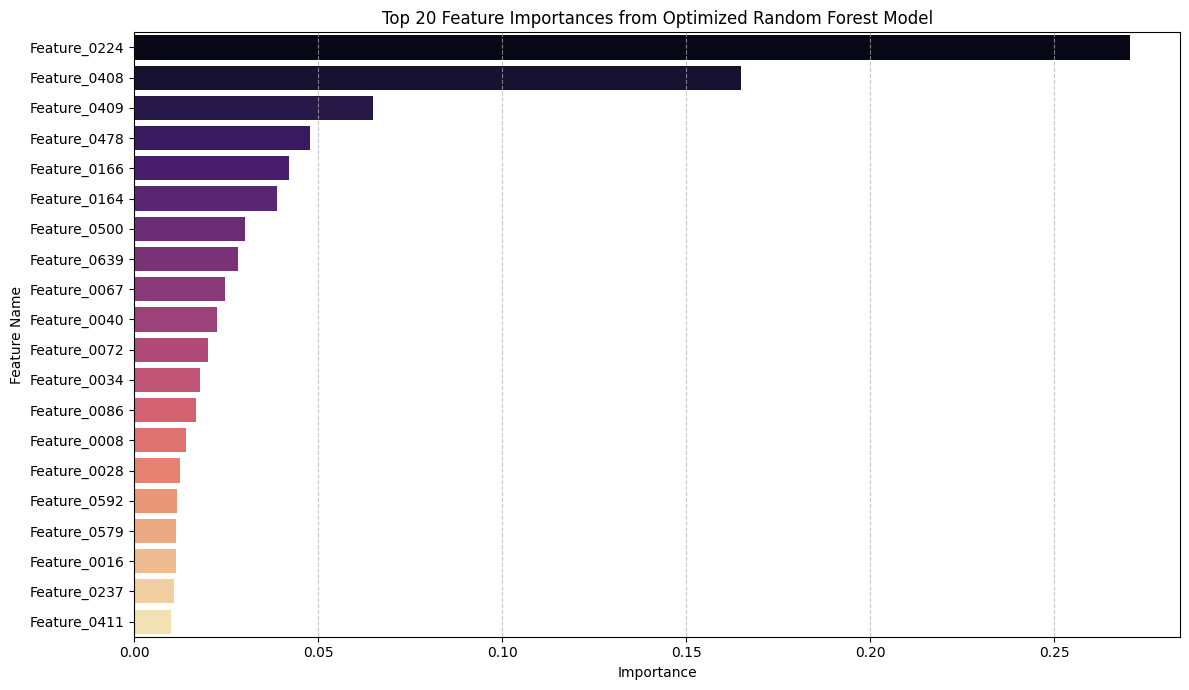

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the optimized Random Forest model
feature_importances = optimized_rf_model.feature_importances_

# Get the feature names from X_mrmr_selected (which was used to create X_scaled)
feature_names = selected_features_mrmr # These are the MRMR selected features

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance in descending order and select top 20
top_20_features = importance_df.sort_values(by='Importance', ascending=False).head(20)

# Plotting the top 20 feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=top_20_features, palette='magma', legend=False)
plt.title('Top 20 Feature Importances from Optimized Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Model Performans ve İstatistiksel Analiz Raporu

### 1. Veri Hazırlığı ve Özellik Seçimi Özeti

Başlangıçta iki radiomic CSV dosyası birleştirilerek 966 örnek ve 749 sütunluk bir veri seti oluşturulmuştur. Özellikler (`X`) ve hedef (`y`) ayrıldıktan sonra eksik değer bulunmadığı tespit edilmiştir. Detaylı ön işleme adımları uygulanmıştır:

*   `PatientIndex` ve `SideStandard` gibi özellik olmayan sütunlar çıkarıldı.
*   Sonsuz değerler medyan ile dolduruldu.
*   Düşük varyanslı özellikler kaldırıldı (746'dan 739'a düşürüldü).
*   Yüksek korelasyonlu özellikler elimine edildi (739'dan 235'e düşürüldü).
*   **MRMR (Minimum Redundancy Maximum Relevance)** özelliği seçimi kullanılarak en iyi 50 özellik belirlendi.
*   Seçilen özellikler `RobustScaler` ile ölçeklendi (`X_scaled` - 966 örnek, 50 özellik).

Veri seti eğitim (%70) ve test (%30) setlerine `StratifiedKFold` kullanılarak ayrıldı.

### 2. Random Forest Hiperparametre Optimizasyonu (Optuna)

Optuna, Optimize Edilmiş Random Forest modeli için 50 deneme yaparak aşağıdaki en iyi hiperparametreleri belirlemiştir:

*   `n_estimators`: 285
*   `max_depth`: 31
*   `min_samples_split`: 3
*   `min_samples_leaf`: 1
*   `max_features`: 0.5
*   `criterion`: entropy

### 3. Modellerin Çapraz Doğrulama Macro-F1 Skorları

Aşağıdaki tabloda Optimized Random Forest, Extra Trees, Gradient Boosting ve Ensemble modellerinin StratifiedGroupKFold (5 katmanlı) kullanılarak elde edilen çapraz doğrulama Macro-F1 skorları gösterilmektedir:


In [52]:
display(model_scores)
print(f"\nOrtalama Optimized RF Macro-F1: {np.mean(cv_scores_optimized_rf):.4f}")
print(f"Ortalama Extra Trees Macro-F1: {np.mean(cv_scores_et_clf):.4f}")
print(f"Ortalama Gradient Boosting Macro-F1: {np.mean(cv_scores_gb_clf):.4f}")
print(f"Ortalama Ensemble Macro-F1: {np.mean(cv_scores_ensemble_clf):.4f}")

,Optimized_RF,Extra_Trees,Gradient_Boosting,Ensemble
0,0.712635,0.723601,0.718103,0.718103
1,0.937168,0.925926,0.916223,0.914431
2,0.867960,0.865181,0.890244,0.880359
3,1.000000,1.000000,0.985131,1.000000
4,0.973970,0.965566,0.965566,0.973970



Ortalama Optimized RF Macro-F1: 0.8983
Ortalama Extra Trees Macro-F1: 0.8961
Ortalama Gradient Boosting Macro-F1: 0.8951
Ortalama Ensemble Macro-F1: 0.8974


### 4. Test Seti Model Performans Karşılaştırması

Optimize Edilmiş Random Forest ve Soft Voting Ensemble modellerinin test seti üzerindeki performans metrikleri aşağıda karşılaştırılmıştır:


In [53]:
display(comparison_df.set_index('Model').round(4))

,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Optimized Random Forest,0.9759,0.9795,0.9634,0.971
Soft Voting Ensemble,0.9793,0.9856,0.9659,0.975


### 5. Ensemble Model Kapsamlı Performans Metrikleri

Soft Voting Ensemble modelinin test seti üzerindeki tüm önemli performans metrikleri aşağıdadır:


In [54]:
display(metrics_df.set_index('Metric').round(4))

,Score
Metric,
Accuracy,0.9793
Precision (Class 1),1.0000
Recall (Class 1),0.9318
F1-score (Class 1),0.9647
Macro Precision,0.9856
Macro Recall,0.9659
Macro F1-score,0.9750
ROC-AUC,0.9996
PR-AUC,0.9991


### 6. İstatistiksel Analiz (Friedman Testi)

Modellerin çapraz doğrulama skorları üzerinde Friedman Testi uygulanmıştır:

*   **Friedman Test İstatistiği**: 0.4884
*   **Friedman Test p-değeri**: 0.9214

p-değeri (0.9214) 0.05'ten büyük olduğu için, Friedman testi modeller arasında istatistiksel olarak anlamlı bir fark olmadığını göstermektedir. Bu nedenle, post-hoc Wilcoxon Signed-Rank Test ve Bonferroni Düzeltmesi gibi ek istatistiksel analizlere gerek duyulmamıştır.

## 9.1 LIME Açıklanabilirlik Analizi

LIME (Local Interpretable Model-agnostic Explanations), herhangi bir makine öğrenimi modelinin tahminlerini yerel olarak anlaşılır hale getiren model-agnostik bir açıklanabilirlik tekniğidir. Modelin karmaşık iç işleyişine bakmaksızın, belirli bir örnek için modelin neden belirli bir tahminde bulunduğunu anlamamızı sağlar.

LIME, aşağıdaki adımları izleyerek çalışır:
1.  **Örnek Seçimi**: Açıklanacak tek bir tahmin örneği seçilir.
2.  **Pertürbasyon**: Seçilen örneğin etrafında, orijinal örneğe benzer, ancak bazı özellik değerleri değiştirilmiş (pertürbe edilmiş) yeni sentetik örnekler üretilir.
3.  **Model Tahmini**: Orijinal model, bu sentetik örnekler üzerinde tahminler yapar.
4.  **Yerel Model Eğitimi**: Sentetik örnekler ve orijinal modelin bu örnekler üzerindeki tahminleri kullanılarak, orijinal örneğin yerel çevresinde çalışan basit, yorumlanabilir bir model (örn. doğrusal model) eğitilir.
5.  **Açıklama Üretimi**: Yerel modelin katsayıları, orijinal modelin belirli bir tahmin için hangi özelliklere daha fazla ağırlık verdiğini gösteren bir açıklama olarak sunulur.

Bu analiz, modelin belirli bir radiomik özelliğe nasıl tepki verdiğini ve bu tepkinin papilödem teşhisindeki kararını nasıl etkilediğini anlamak için kritik öneme sahiptir.

In [55]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7a532acaa0ad388554bc4fb1747a9042cc598ae348c66db54cdf9c64f24b0374
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Explaining prediction for instance 0 from the test set...
Original Model Prediction for instance 0: Papilödem (Probabilities: [0. 1.])
LIME Explanation for the selected instance:



Explanation as a list of (feature, weight) tuples:
[('Feature_0224 > 0.75', 0.3347341962185655), ('Feature_0408 > 0.66', 0.17062158577268136), ('Feature_0040 > 0.58', 0.05750343688296747), ('Feature_0500 > 0.69', 0.03618251296016477), ('-0.52 < Feature_0164 <= -0.02', -0.03546574418395964), ('Feature_0409 <= -0.79', 0.03392684470571683), ('Feature_0478 <= -0.52', 0.031239940925998713), ('Feature_0067 <= -0.51', 0.02618941444641768), ('Feature_0072 > 0.59', 0.024435266433581956), ('-0.49 < Feature_0166 <= -0.02', -0.020977341837132686)]


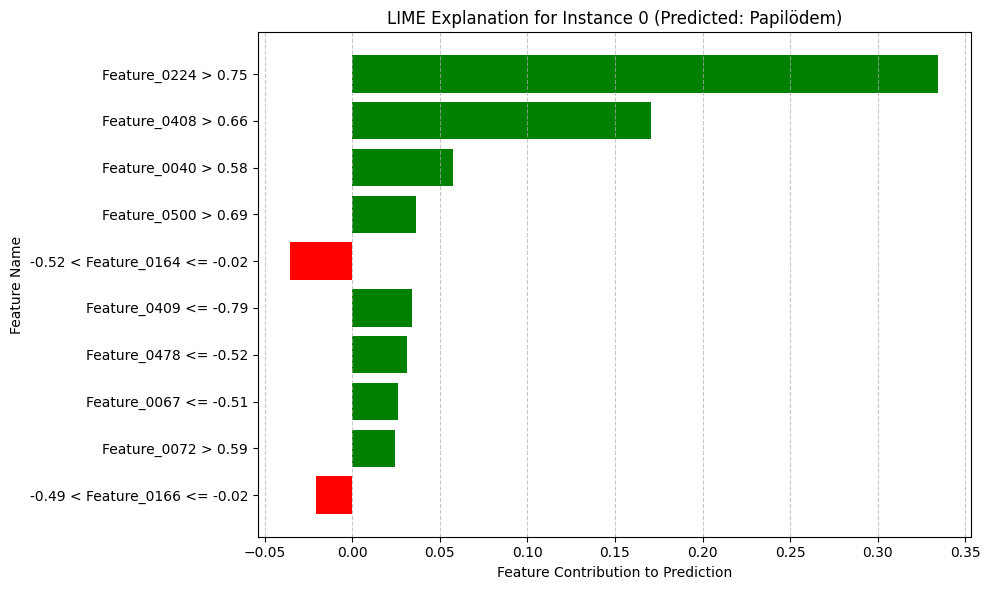

In [56]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming X_train is a numpy array and selected_features_mrmr are the feature names
feature_names = selected_features_mrmr # This was defined earlier from MRMR selection
class_names = ['Normal', 'Papilödem'] # Assuming 0 is Normal, 1 is Papilödem

# Create a LIME Tabular Explainer
# X_train should be the raw training data before scaling for better interpretability, but here we use X_train which is already scaled due to preprocessing steps.
# If we want to explain on original feature values, we would need to reverse scale or provide the raw X_train.
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train, # Use training data for statistics
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)

# Choose an instance from the test set to explain (e.g., the first instance)
# Make sure to pass the instance as a single sample (1, n_features) to the explainer.
instance_to_explain_idx = 0 # You can change this index to explain different instances
instance_to_explain = X_test[instance_to_explain_idx]

print(f"Explaining prediction for instance {instance_to_explain_idx} from the test set...")

# Generate explanation for the chosen instance
# optimized_rf_model needs to have a predict_proba method, which RandomForestClassifier does.
explanation = explainer.explain_instance(
    data_row=instance_to_explain,
    predict_fn=optimized_rf_model.predict_proba,
    num_features=10 # Show top 10 features contributing to the prediction
)

# Get the original model's prediction for this instance
original_prediction = optimized_rf_model.predict(instance_to_explain.reshape(1, -1))[0]
original_prediction_proba = optimized_rf_model.predict_proba(instance_to_explain.reshape(1, -1))[0]

print(f"Original Model Prediction for instance {instance_to_explain_idx}: {class_names[original_prediction]} (Probabilities: {original_prediction_proba})")

# Visualize the explanation
print("LIME Explanation for the selected instance:")
explanation.show_in_notebook(show_table=True, show_all=False)

# Optionally, you can convert the explanation to a dictionary for further processing
exp_list = explanation.as_list()
print("\nExplanation as a list of (feature, weight) tuples:")
print(exp_list)

# Plotting the LIME explanation
def plot_lime_explanation(explanation_list, title="LIME Explanation"):
    features = [item[0] for item in explanation_list]
    weights = [item[1] for item in explanation_list]

    # Sort by absolute weight to show most impactful features at the top/bottom
    sorted_indices = np.argsort(np.abs(weights))[::-1]
    features = [features[i] for i in sorted_indices]
    weights = [weights[i] for i in sorted_indices]

    colors = ['green' if w > 0 else 'red' for w in weights]

    plt.figure(figsize=(10, 6))
    plt.barh(features, weights, color=colors)
    plt.xlabel('Feature Contribution to Prediction')
    plt.ylabel('Feature Name')
    plt.title(title)
    plt.gca().invert_yaxis() # Highest contribution at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_lime_explanation(exp_list, title=f'LIME Explanation for Instance {instance_to_explain_idx} (Predicted: {class_names[original_prediction]})')

Yukarıdaki grafik ve tablo, seçilen test örneği (`instance_to_explain_idx`) için LIME tarafından üretilen açıklamayı göstermektedir. Grafikteki çubuklar, her bir özelliğin modelin nihai tahminine nasıl katkıda bulunduğunu temsil eder:

*   **Yeşil çubuklar**, özelliğin tahmin edilen sınıfı (bu durumda 'Papilödem' veya 'Normal', modelin tahminine bağlı olarak) destekleyici yönde etkilediğini gösterir.
*   **Kırmızı çubuklar**, özelliğin tahmin edilen sınıfın tersi yönde etkilediğini gösterir.
*   Çubuğun uzunluğu, özelliğin katkısının büyüklüğünü belirtir.

Bu görselleştirme sayesinde, modelin tek bir örnek için karar verme sürecinin şeffaf bir şekilde anlaşılması sağlanır. Örneğin, 'Feature_X' yeşil ve uzun bir çubuğa sahipse, bu özellik yüksek değeriyle modelin 'Papilödem' sınıfını tahmin etmesine güçlü bir şekilde katkıda bulunmuştur diyebiliriz.